<a href="https://colab.research.google.com/github/victorm0202/temas_selectos_CD_2026/blob/main/Text_classification_%2B_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embeddings layers for text classification

In [ ]:
import numpy as np
import torch

print("PyTorch Version : {}".format(torch.__version__))

PyTorch Version : 2.9.1


In [ ]:
import platform
if platform.system() == 'Darwin': #si es macOS
    av1 = torch.backends.mps.is_available()
    # this ensures that the current PyTorch installation was built with MPS activated.
    av2 = torch.backends.mps.is_built()
    if(av1==av2==True):
        print('MPS available?',av1,'MPS built?',av2)
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
else:
    #Check if GPU is available
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
print("Device:",device)

MPS available? True MPS built? True
Device: mps


## The dataset

We will use AG NEWS dataset available from torchtext library. It has text documents for 4 different categories `["World", "Sports", "Business", "Sci/Tech"]`. The dataset is already divided into train and test sets.

In [ ]:
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer
from torch.utils.data import DataLoader

ag_news = load_dataset("ag_news")

train_dataset = ag_news["train"]
test_dataset = ag_news["test"]

target_classes = ag_news["train"].features["label"].names
target_classes

['World', 'Sports', 'Business', 'Sci/Tech']

## Tokenize Text Data And Build Vocabulary

In [ ]:
#MAX_LEN = 10
MAX_LEN = 50

def batch_iterator(dataset, batch_size=1000):
    for i in range(0, len(dataset), batch_size):
        yield dataset[i:i + batch_size]["text"]

tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = WordLevelTrainer(
    special_tokens=["[PAD]", "[UNK]"],
    min_frequency=2
)

tokenizer.train_from_iterator(
    batch_iterator(train_dataset),
    trainer=trainer
)

pad_id = tokenizer.token_to_id("[PAD]")
unk_id = tokenizer.token_to_id("[UNK]")

tokenizer.enable_truncation(max_length=MAX_LEN)
tokenizer.enable_padding(
    length=MAX_LEN,
    pad_id=pad_id,
    pad_token="[PAD]"
)

vocab_size = tokenizer.get_vocab_size()

vocab_size, pad_id, unk_id

(30000, 0, 1)

In [ ]:
encoding = tokenizer.encode("Hello how are you?")

tokens = encoding.tokens
ids = encoding.ids

tokens, ids

(['Hello',
  'how',
  'are',
  'you',
  '?',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]'],
 [18445,
  477,
  53,
  207,
  92,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0])

## Data Loaders (Vectorize Text Data)

We have decided to keep a maximum of 50 words per document. To handle that condition, we have truncated words from documents that have more than 50 words and padded documents (with zeros) to documents that have less than 50 words. The number of words to keep per document is one of the hyperparameters to train. We have kept it at 50 but different values can be tried to check whether any helps improve the accuracy of the model

In [ ]:
def vectorize_batch(batch):
    texts = [example["text"] for example in batch]
    labels = [example["label"] for example in batch]

    encodings = tokenizer.encode_batch(texts)

    X = [encoding.ids for encoding in encodings]
    Y = labels

    return (
        torch.tensor(X, dtype=torch.long).to(device),
        torch.tensor(Y, dtype=torch.long).to(device)
    )

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    collate_fn=vectorize_batch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False,
    collate_fn=vectorize_batch
)

## A model with a simple embedding layer

In [ ]:
from torch import nn
from torch.nn import functional as F

class EmbeddingClassifier(nn.Module):
    def __init__(self):
        super(EmbeddingClassifier, self).__init__()

        self.seq = nn.Sequential(
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=25,
                padding_idx=pad_id
            ),

            nn.Flatten(),

            nn.Linear(25 * MAX_LEN, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, len(target_classes)),
        )

    def forward(self, X_batch):
        return self.seq(X_batch)

In [ ]:
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score
import gc

def CalcValLossAndAccuracy(model, loss_fn, val_loader):
    with torch.no_grad():
        Y_shuffled, Y_preds, losses = [],[],[]
        for X, Y in tqdm(val_loader):
            X = X.to(device)
            Y = Y.to(device)
            preds = model(X)
            loss = loss_fn(preds, Y)
            losses.append(loss.item())

            Y_shuffled.append(Y)
            Y_preds.append(preds.argmax(dim=-1))

        Y_shuffled = torch.cat(Y_shuffled)
        Y_preds = torch.cat(Y_preds)

        print("Valid Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Valid Acc  : {:.3f}".format(accuracy_score(Y_shuffled.detach().cpu().numpy(), Y_preds.detach().cpu().numpy())))


def TrainModel(model, loss_fn, optimizer, train_loader, val_loader, epochs=10):
    for i in range(1, epochs+1):
        losses = []
        for X, Y in tqdm(train_loader):
            X = X.to(device)
            Y = Y.to(device)
            Y_preds = model(X)

            loss = loss_fn(Y_preds, Y)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
        CalcValLossAndAccuracy(model, loss_fn, val_loader)


### Training and evaluate the model

In [ ]:
from torch.optim import Adam

epochs = 15
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
embed_classifier = EmbeddingClassifier()
# Send model to `device` (GPU/CPU)
embed_classifier.to(device)
optimizer = Adam(embed_classifier.parameters(), lr=learning_rate)

TrainModel(embed_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)

  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 1.168


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.968
Valid Acc  : 0.600


  0%|          | 0/118 [00:00<?, ?it/s]

...

Valid Loss : 1.154
Valid Acc  : 0.813


  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 0.005


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 1.162
Valid Acc  : 0.814


In [ ]:
def MakePredictions(model, loader):
    Y_shuffled, Y_preds = [], []
    for X, Y in loader:
        X = X.to(device)
        Y = Y.to(device)
        preds = model(X)
        Y_preds.append(preds)
        Y_shuffled.append(Y)
    gc.collect()
    Y_preds, Y_shuffled = torch.cat(Y_preds), torch.cat(Y_shuffled)

    return Y_shuffled.detach().cpu().numpy(), F.softmax(Y_preds, dim=-1).argmax(dim=-1).detach().cpu().numpy()

Y_actual, Y_preds = MakePredictions(embed_classifier, test_loader)

Test Accuracy : 0.8136842105263158

Classification Report : 
              precision    recall  f1-score   support

       World       0.82      0.82      0.82      1900
      Sports       0.90      0.89      0.90      1900
    Business       0.76      0.76      0.76      1900
    Sci/Tech       0.77      0.78      0.78      1900

    accuracy                           0.81      7600
   macro avg       0.81      0.81      0.81      7600
weighted avg       0.81      0.81      0.81      7600



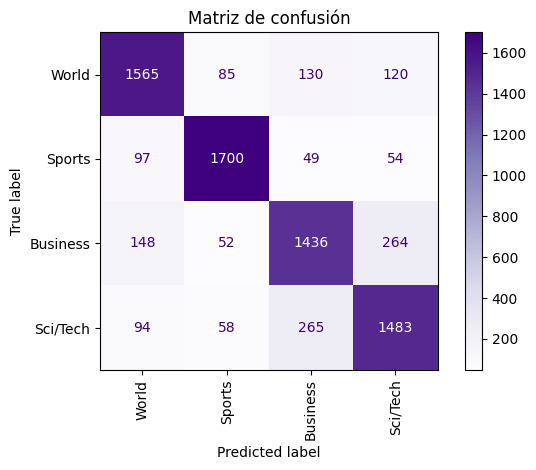

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

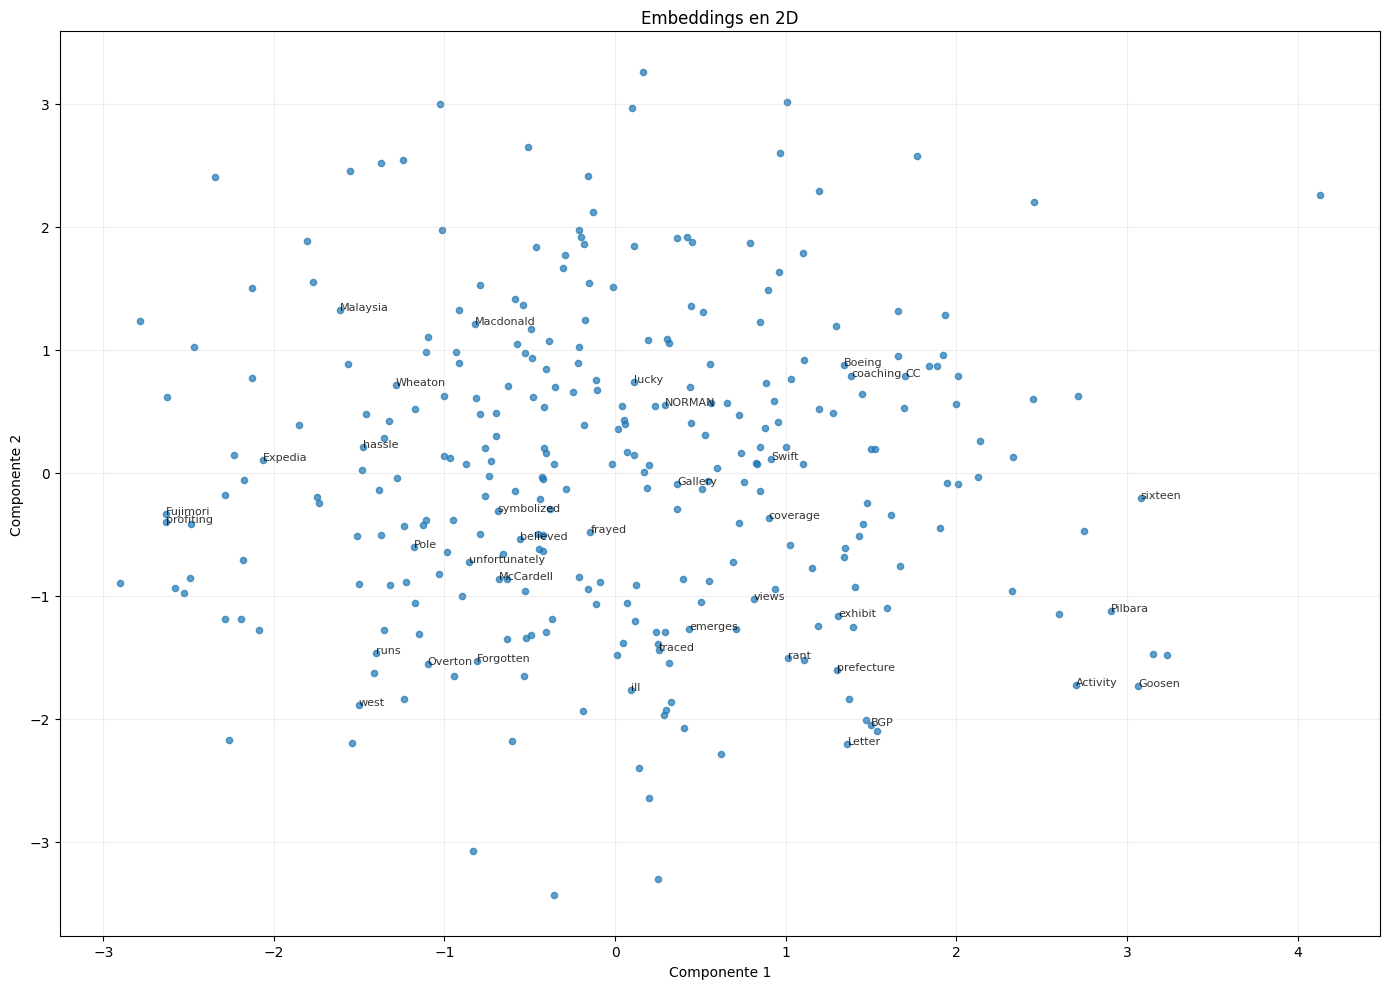

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch import nn

def get_embedding_layer(model):
    if hasattr(model, "word_embeddings"):
        return model.word_embeddings
    if hasattr(model, "seq") and len(model.seq) > 0 and isinstance(model.seq[0], nn.Embedding):
        return model.seq[0]
    raise AttributeError("No se encontró una capa de embeddings en el modelo.")

# Extraer embeddings
embedding_layer = get_embedding_layer(embed_classifier)
emb_matrix = embedding_layer.weight.detach().cpu().numpy()

# Token -> id y luego id -> token
vocab = tokenizer.get_vocab()
id_to_token = {idx: tok for tok, idx in vocab.items()}

# Elegir tokens para graficar
tokens_to_plot = []
for idx in range(len(id_to_token)):
    tok = id_to_token[idx]
    if tok not in ["[PAD]", "[UNK]"]:
        tokens_to_plot.append((idx, tok))

# Tomar una muestra para no saturar la figura
n_points = 300
if len(tokens_to_plot) > n_points:
    rng = np.random.default_rng(42)
    chosen = rng.choice(len(tokens_to_plot), size=n_points, replace=False)
    tokens_to_plot = [tokens_to_plot[i] for i in chosen]

indices = [idx for idx, _ in tokens_to_plot]
labels = [tok for _, tok in tokens_to_plot]
X = emb_matrix[indices]

# Proyección a 2D
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

# Gráfica
plt.figure(figsize=(14, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=20, alpha=0.7)

for i, label in enumerate(labels):
    if i % 8 == 0:
        plt.annotate(label, (X_2d[i, 0], X_2d[i, 1]), fontsize=8, alpha=0.8)

plt.title("Embeddings en 2D")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## A model with Average Word Embeddings

In the first model, we were keeping embeddings for all words/tokens of the text example by laying them next to each other, but in this model, we have taken the average of embeddings of all tokens/words per text example.

In [ ]:
class EmbeddingClassifier(nn.Module):
    def __init__(self):
        super(EmbeddingClassifier, self).__init__()

        self.word_embeddings = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=25,
            padding_idx=pad_id
        )

        self.linear1 = nn.Linear(25, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, len(target_classes))

    def forward(self, X_batch):
        x = self.word_embeddings(X_batch)
        x = x.mean(dim=1)

        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        logits = self.linear3(x)

        return logits

### Training and evaluate the model

In [ ]:
from torch.optim import Adam

epochs = 15
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
embed_classifier = EmbeddingClassifier()
embed_classifier.to(device)
optimizer = Adam(embed_classifier.parameters(), lr=learning_rate)

TrainModel(embed_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)

  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 1.179


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.861
Valid Acc  : 0.653


  0%|          | 0/118 [00:00<?, ?it/s]

...

Valid Loss : 0.298
Valid Acc  : 0.901


  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 0.185


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.296
Valid Acc  : 0.902


Test Accuracy : 0.9017105263157895

Classification Report : 
              precision    recall  f1-score   support

       World       0.92      0.88      0.90      1900
      Sports       0.94      0.97      0.96      1900
    Business       0.88      0.85      0.87      1900
    Sci/Tech       0.87      0.90      0.89      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



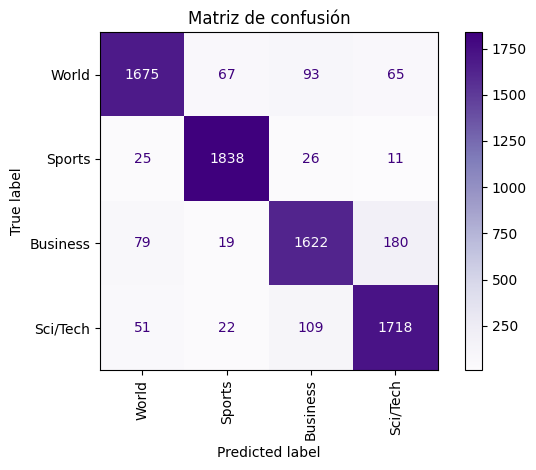

In [ ]:
Y_actual, Y_preds = MakePredictions(embed_classifier, test_loader)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

## A model with pre-trained embeddings (fastText)

We will use fastText pretrained word vectors (Mikolov et al., 2017), trained on 600 billion tokens on Common Crawl. fastText is an upgraded version of word2vec and outperform other state-of-the-art methods by a large margin.

The code below will download fastText pretrained vectors. Using Google Colab, the running time is approximately 3min 30s.

In [ ]:
import os
import numpy as np
import pandas as pd

In [ ]:
%%time
URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip"
FILE = "fastText"

if os.path.isdir(FILE):
    print("fastText exists.")
else:
    !wget -P $FILE $URL
    !unzip $FILE/crawl-300d-2M.vec.zip -d $FILE

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


--2026-07-16 16:27:08--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 52.84.217.124, 52.84.217.55, 52.84.217.5, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|52.84.217.124|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1523785255 (1.4G) [application/zip]
Saving to: ‘fastText/crawl-300d-2M.vec.zip’

crawl-300d-2M.vec.z 100%[===================>]   1.42G  7.12MB/s    in 3m 51s  

2026-07-16 16:30:59 (6.30 MB/s) - ‘fastText/crawl-300d-2M.vec.zip’ saved [1523785255/1523785255]

Archive:  fastText/crawl-300d-2M.vec.zip
  inflating: fastText/crawl-300d-2M.vec  

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



CPU times: user 3.16 s, sys: 1.1 s, total: 4.26 s
Wall time: 4min 21s


We will load the pretrain vectors for each tokens in our vocabulary. For tokens with no pretraiend vectors, we will initialize random word vectors with the same length and variance.

In [ ]:
import numpy as np
import torch
#from tqdm import tqdm

def load_pretrained_vectors(tokenizer, fname):
    """
    Carga vectores preentrenados fastText y construye una matriz
    de embeddings alineada con el vocabulario del tokenizer.
    """

    print("Loading pretrained vectors...")

    with open(fname, "r", encoding="utf-8", newline="\n", errors="ignore") as fin:
        n, d = map(int, fin.readline().split())

        embeddings = np.random.uniform(
            -0.25,
            0.25,
            (tokenizer.get_vocab_size(), d)
        ).astype(np.float32)

        pad_id = tokenizer.token_to_id("[PAD]")
        if pad_id is not None:
            embeddings[pad_id] = np.zeros(d, dtype=np.float32)

        count = 0

        for line in tqdm(fin, total=n):
            values = line.rstrip().split(" ")
            word = values[0]

            word_id = tokenizer.token_to_id(word)

            if word_id is not None:
                embeddings[word_id] = np.asarray(values[1:], dtype=np.float32)
                count += 1

    print(f"There are {count} / {tokenizer.get_vocab_size()} pretrained vectors found.")

    return embeddings

In [ ]:
# Load pretrained vectors
embeddings = load_pretrained_vectors(
    tokenizer,
    "fastText/crawl-300d-2M.vec"
)

embeddings = torch.tensor(
    embeddings,
    dtype=torch.float32
).to(device)

embeddings.shape

Loading pretrained vectors...


100%|██████████| 1999995/1999995 [00:17<00:00, 113711.12it/s]


There are 29624 / 30000 pretrained vectors found.


torch.Size([30000, 300])

### The model

In [ ]:
from torch import nn
from torch.nn import functional as F

class EmbeddingClassifier(nn.Module):
    def __init__(self, pretrained_emb, freeze_embedding=True):
        super(EmbeddingClassifier, self).__init__()

        self.vocab_size, self.embed_dim = pretrained_emb.shape

        self.word_embeddings = nn.Embedding.from_pretrained(
            pretrained_emb,
            freeze=freeze_embedding,
            padding_idx=pad_id
        )

        self.linear1 = nn.Linear(self.embed_dim, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, len(target_classes))

    def forward(self, X_batch):
        x = self.word_embeddings(X_batch)

        mask = (X_batch != pad_id).unsqueeze(-1)
        x = x * mask

        lengths = mask.sum(dim=1).clamp(min=1)
        x = x.sum(dim=1) / lengths

        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        logits = self.linear3(x)

        return logits

Just to check embedding size...

In [ ]:
embed_classifier = EmbeddingClassifier(embeddings, freeze_embedding=True)
embed_classifier.to(device)

embed_classifier.embed_dim

300

### Training and evaluation

In [ ]:
epochs = 15
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()

embed_classifier = EmbeddingClassifier(
    embeddings,
    freeze_embedding=True
).to(device)

optimizer = Adam(
    embed_classifier.parameters(),
    lr=learning_rate
)

TrainModel(
    embed_classifier,
    loss_fn,
    optimizer,
    train_loader,
    test_loader,
    epochs
)

100%|██████████| 118/118 [00:04<00:00, 27.02it/s]


Train Loss : 0.687


100%|██████████| 8/8 [00:00<00:00, 35.71it/s]


Valid Loss : 0.333
Valid Acc  : 0.887


100%|██████████| 118/118 [00:03<00:00, 35.40it/s]


...

Valid Loss : 0.245
Valid Acc  : 0.912


100%|██████████| 118/118 [00:03<00:00, 35.78it/s]


Train Loss : 0.223


100%|██████████| 8/8 [00:00<00:00, 39.86it/s]

Valid Loss : 0.242
Valid Acc  : 0.914


Test Accuracy : 0.9136842105263158

Classification Report : 
              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.88      0.87      0.88      1900
    Sci/Tech       0.88      0.90      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



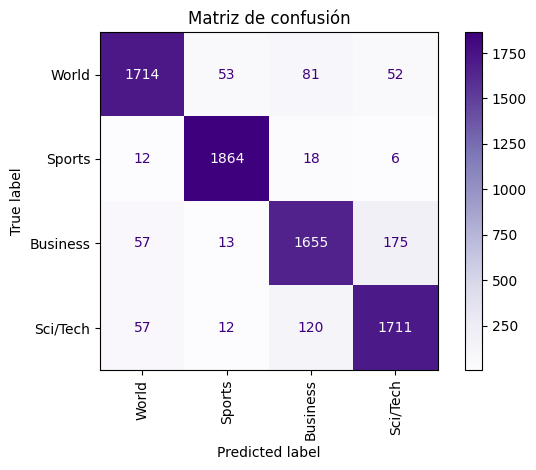

In [ ]:
Y_actual, Y_preds = MakePredictions(embed_classifier, test_loader)

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

A test unfreezing the pre-trained embeddings layer:

In [ ]:
epochs = 15
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()

embed_classifier = EmbeddingClassifier(
    embeddings,
    freeze_embedding=False
).to(device)

optimizer = Adam(
    embed_classifier.parameters(),
    lr=learning_rate
)

TrainModel(
    embed_classifier,
    loss_fn,
    optimizer,
    train_loader,
    test_loader,
    epochs
)

100%|██████████| 118/118 [00:04<00:00, 28.88it/s]


Train Loss : 0.612


100%|██████████| 8/8 [00:00<00:00, 40.60it/s]


Valid Loss : 0.267
Valid Acc  : 0.911


100%|██████████| 118/118 [00:03<00:00, 39.31it/s]


...

Valid Loss : 0.625
Valid Acc  : 0.904


100%|██████████| 118/118 [00:03<00:00, 32.97it/s]


Train Loss : 0.016


100%|██████████| 8/8 [00:00<00:00, 36.27it/s]

Valid Loss : 0.650
Valid Acc  : 0.901


Test Accuracy : 0.9005263157894737

Classification Report : 
              precision    recall  f1-score   support

       World       0.91      0.90      0.90      1900
      Sports       0.96      0.97      0.96      1900
    Business       0.86      0.87      0.86      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



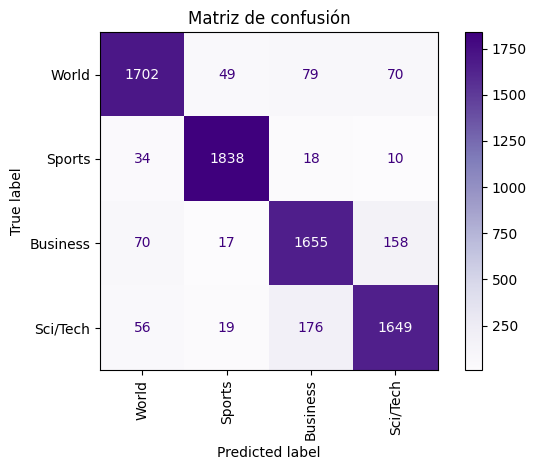

In [ ]:
Y_actual, Y_preds = MakePredictions(embed_classifier, test_loader)

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()